##Data Understanding dan Exploratory Data Analysis (EDA)

Sesi ini melanjutkan pengenalan AI dan Google Colab ke tahap yang lebih praktis, yaitu memahami isi data sebelum membuat model. EDA penting karena membantu melihat struktur data, mendeteksi missing value, outlier, pola distribusi, dan hubungan antarvariabel sebelum masuk ke preprocessing atau machine learning.

## 1. Landasan Konseptual: Mengapa EDA Penting?

EDA merupakan tahap eksplorasi sistematis untuk mengidentifikasi pola, anomali, dan hubungan dalam data sebelum formulasi model prediktif. Secara metodologis, EDA menjawab pertanyaan fundamental:
- Variabel apa yang tersedia dan bagaimana karakteristiknya?
- Apakah terdapat nilai yang hilang atau tidak konsisten?
- Adakah pola distribusi yang mengarahkan pada asumsi statistik tertentu?
- Variabel mana yang menunjukkan korelasi potensial?

Dalam konteks teknik industri, EDA diterapkan pada analisis data historis proses manufaktur, evaluasi indikator kinerja operasional, identifikasi faktor kualitas, dan deteksi awal gangguan proses

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi default seaborn agar lebih profesional
sns.set_theme()

# Konfirmasi bahwa semua library telah ter-load
print('Library siap digunakan')


Library siap digunakan


In [ ]:
# =============================================================================
# ALTERNATIF: MEMBUAT DATA SECARA PROGRAMATIK
# =============================================================================
data = {
    'Tanggal': ['2026-01-05','2026-01-05','2026-01-06','2026-01-06','2026-01-07','2026-01-07','2026-01-08','2026-01-08','2026-01-09','2026-01-09','2026-01-10','2026-01-10','2026-01-11','2026-01-11'],
    'Shift': ['Pagi','Siang','Pagi','Siang','Pagi','Siang','Pagi','Siang','Pagi','Siang','Pagi','Siang','Pagi','Siang'],
    'Mesin': ['M1','M1','M1','M1','M2','M2','M2','M2','M1','M1','M2','M2','M1','M1'],
    'Output_Unit': [120,118,135,132,128,125,140,138,150,146,142,139,131,129],
    'Downtime_Menit': [30,35,25,28,40,42,20,22,15,18,24,26,33,36],
    'Defect_Unit': [5,6,4,5,6,7,3,4,2,3,4,4,5,6],
    'Operator_Hadir': [8,8,8,8,7,7,8,8,8,8,7,7,8,8],
    'Suhu_Mesin': [72,74,70,71,79,81,69,70,67,68,73,75,76,77],
    'Target_Unit': [130,130,130,130,130,130,135,135,140,140,138,138,132,132]
}

# pd.DataFrame() mengubah kamus data menjadi tabel DataFrame
df = pd.DataFrame(data)

# =============================================================================
# MENAMPILKAN 5 BARIS PERTAMA DATA
# =============================================================================
# Menampilkan 5 baris pertama
df.head()

,Tanggal,Shift,Mesin,Output_Unit,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Target_Unit
0,2026-01-05,Pagi,M1,120,30,5,8,72,130
1,2026-01-05,Siang,M1,118,35,6,8,74,130
2,2026-01-06,Pagi,M1,135,25,4,8,70,130
3,2026-01-06,Siang,M1,132,28,5,8,71,130
4,2026-01-07,Pagi,M2,128,40,6,7,79,130


## 4. Prosedur Sistematis Eksplorasi Data Awal

Untuk konsistensi metodologis, urutan kerja EDA direkomendasikan sebagai berikut:
1. Inspeksi 5 baris awal untuk memahami struktur data.
2. Verifikasi tipe data setiap kolom.
3. Tinjau statistik deskriptif (mean, std, min, max, kuartil).
4. Identifikasi missing value.
5. Baru kemudian lanjut ke visualisasi.

Urutan ini meminimalkan kebingungan dan memastikan pemahaman komprehensif sebelum analisis lanjut.

In [ ]:
# =============================================================================
# MEMERIKSA TIPA DATA DAN INFORMASI KOLOM
# =============================================================================
# df.info() menampilkan:
# - Jumlah baris non-null
# - Tipe data setiap kolom (int64, float64, object)
# - Jumlah memori yang digunakan
# Informasi ini penting untuk menilai kualitas data awal
df.head()

,Tanggal,Shift,Mesin,Output_Unit,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Target_Unit
0,2026-01-05,Pagi,M1,120,30,5,8,72,130
1,2026-01-05,Siang,M1,118,35,6,8,74,130
2,2026-01-06,Pagi,M1,135,25,4,8,70,130
3,2026-01-06,Siang,M1,132,28,5,8,71,130
4,2026-01-07,Pagi,M2,128,40,6,7,79,130


In [ ]:
# =============================================================================
# STATISTIK DESKRIPTIF UNTUK VARIABEL NUMERIK
# =============================================================================
# df.describe() menghasilkan:
# - count: jumlah observasi
# - mean: rata-rata
# - std: simpangan baku (sebaran data)
# - min, max: nilai terendah dan tertinggi
# - 25%, 50%, 75%: kuartil pertama, median, kuartil ketiga
# Statistik ini memberikan gambaran sentral dan sebaran data numerik

df.describe()

,Output_Unit,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Target_Unit
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,133.785714,28.142857,4.571429,7.714286,73.000000,133.571429
std,9.398679,8.226198,1.398586,0.468807,4.206222,3.994502
min,118.000000,15.000000,2.000000,7.000000,67.000000,130.000000
25%,128.250000,22.500000,4.000000,7.250000,70.000000,130.000000
50%,133.500000,27.000000,4.500000,8.000000,72.500000,132.000000
75%,139.750000,34.500000,5.750000,8.000000,75.750000,137.250000
max,150.000000,42.000000,7.000000,8.000000,81.000000,140.000000


## 5. Deteksi Missing Value (Nilai Hilang)

Missing value merupakan masalah umum dalam data industri yang dapat menyebabkan bias analisis jika tidak ditangani. Fungsi `isnull().sum()` menghitung jumlah nilai kosong per kolom. Nilai 0 menunjukkan data lengkap.

In [ ]:
# =============================================================================
# MENGHITUNG JUMLAH MISSING VALUE PER KOLOM
# =============================================================================
# df.isnull() mengembalikan boolean True untuk sel yang kosong
# .sum() menjumlahkan True per kolom (True = 1, False = 0)
# Hasil menunjukkan berapa banyak nilai kosong di setiap kolom

df.isnull().sum()

,0
Tanggal,0
Shift,0
Mesin,0
Output_Unit,0
Downtime_Menit,0
Defect_Unit,0
Operator_Hadir,0
Suhu_Mesin,0
Target_Unit,0


## 6. Rekayasa Fitur Sederhana untuk Kontekstualisasi

Variabel turunan dapat dibuat untuk memperkuat interpretasi operasional:
- **Selisih_Target**: selisih antara output aktual dan target (indikator kinerja).
- **Defect_Rate**: rasio defect terhadap output (indikator kualitas).

Fitur ini menghubungkan angka mentah dengan metrik kinerja proses.

In [ ]:
# =============================================================================
# MEMBUAT VARIABEL TURUNAN: SELISIH_TARGET DAN DEFECT_RATE
# =============================================================================
# df['Kolom'] = ekspresi matematika untuk membuat kolom baru
# Selisih_Target = Output_Unit - Target_Unit (positif = mencapai target, negatif = belum)
# Defect_Rate = Defect_Unit / Output_Unit (rasio defect, semakin kecil semakin baik)

df['Selisih_Target'] = df['Output_Unit'] - df['Target_Unit']
df['Defect_Rate'] = df['Defect_Unit'] / df['Output_Unit']

# Menampilkan 5 baris pertama dengan kolom baru
df.head()


,Tanggal,Shift,Mesin,Output_Unit,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Target_Unit,Selisih_Target,Defect_Rate
0,2026-01-05,Pagi,M1,120,30,5,8,72,130,-10,0.041667
1,2026-01-05,Siang,M1,118,35,6,8,74,130,-12,0.050847
2,2026-01-06,Pagi,M1,135,25,4,8,70,130,5,0.029630
3,2026-01-06,Siang,M1,132,28,5,8,71,130,2,0.037879
4,2026-01-07,Pagi,M2,128,40,6,7,79,130,-2,0.046875


## 7. Visualisasi Univariat: Histogram Distribusi

Histogram menampilkan frekuensi kemunculan nilai dalam interval (bin). Untuk data produksi, histogram output membantu mengidentifikasi apakah produksi cenderung stabil atau fluktuatif.

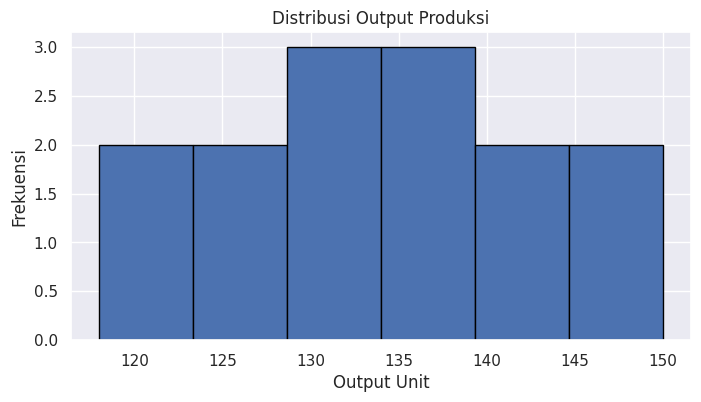

In [ ]:
# =============================================================================
# HISTOG RAM DISTRIBUSI OUTPUT PRODUKSI
# =============================================================================
# plt.figure(figsize=(8,4)): mengatur ukuran grafik (lebar=8, tinggi=4 inci)
# plt.hist(): membuat histogram
# bins=6: membagi data menjadi 6 interval
# edgecolor='black': memberi garis hitam di tepi setiap batang

plt.figure(figsize=(8,4))
plt.hist(df['Output_Unit'], bins=6, edgecolor='black')
plt.title('Distribusi Output Produksi')
plt.xlabel('Output Unit')
plt.ylabel('Frekuensi')
plt.show()

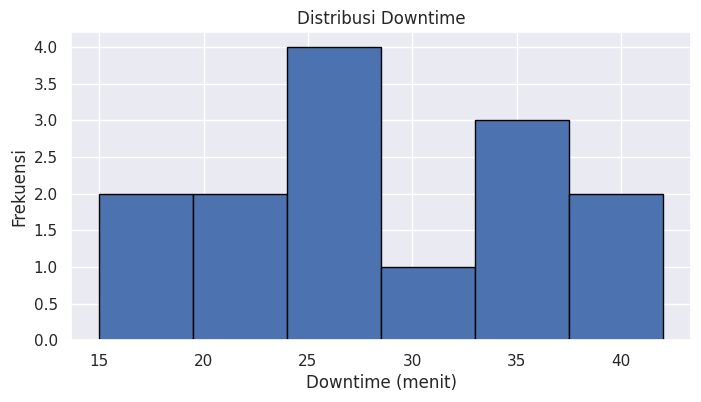

In [ ]:
# =============================================================================
# HISTOGRAM DISTRIBUSI DOWNTIME
# =============================================================================
# Histogram downtime membantu melihat sebaran durasi henti produksi
# Downtime yang tinggi dapat mengindikasikan masalah mesin atau operasional

plt.figure(figsize=(8,4))
plt.hist(df['Downtime_Menit'], bins=6, edgecolor='black')
plt.title('Distribusi Downtime')
plt.xlabel('Downtime (menit)')
plt.ylabel('Frekuensi')
plt.show()

## 8. Visualisasi Univariat: Boxplot untuk Deteksi Anomali

Boxplot menampilkan median, kuartil, dan outlier (nilai ekstrem). Dalam konteks industri, boxplot berguna untuk membandingkan variasi antar-mesin atau antarkelompok.

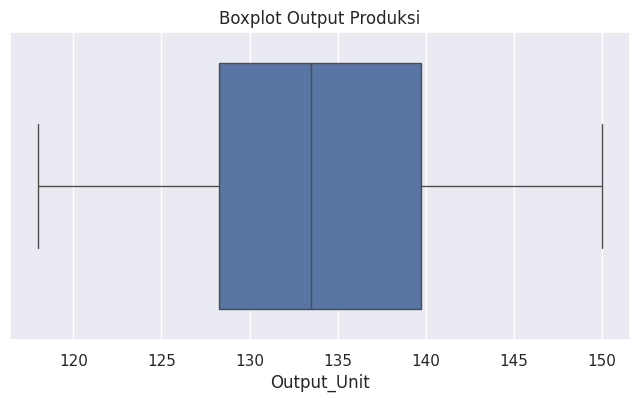

In [ ]:
# =============================================================================
# BOXPLOT OUTPUT PRODUKSI
# =============================================================================
# sns.boxplot(): membuat boxplot dengan seaborn
# Boxplot menunjukkan:
# - Garis tengah: median
# - Kotak: kuartil 25-75%
# - Garis (whisker): rentang data normal
# - Titik di luar: outlier

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Output_Unit'])
plt.title('Boxplot Output Produksi')
plt.show()

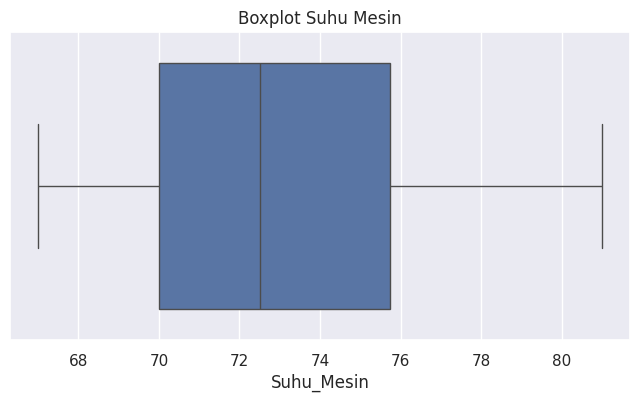

In [ ]:
# =============================================================================
# BOXPLOT SUHU MESIN
# =============================================================================
# Suhu mesin yang ekstrem dapat mengindikasikan risiko kerusakan atau ketidakstabilan proses

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Suhu_Mesin'])
plt.title('Boxplot Suhu Mesin')
plt.show()

## 9. Visualisasi Kategori: Perbandingan Rata-Rata Antar-Kelompok

Variabel kategorikal seperti Shift dan Mesin dapat dibandingkan dengan bar chart pada rata-rata metrik kinerja.

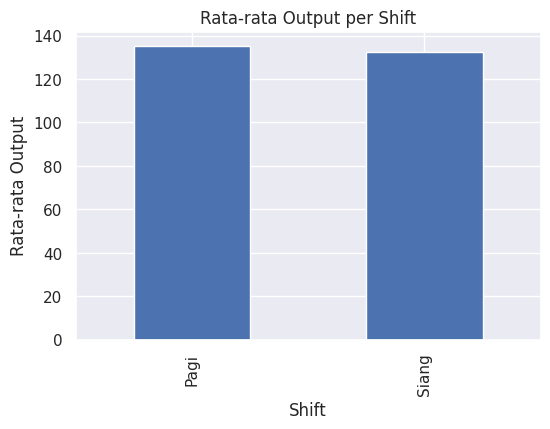

In [ ]:
# =============================================================================
# RATA-RATA OUTPUT PER SHIFT
# =============================================================================
# df.groupby('Shift')['Output_Unit'].mean(): mengelompokkan data per shift, lalu hitung rata-rata output
# .plot(kind='bar'): membuat bar chart

avg_output_shift = df.groupby('Shift')['Output_Unit'].mean()
avg_output_shift.plot(kind='bar', figsize=(6,4), title='Rata-rata Output per Shift')
plt.ylabel('Rata-rata Output')
plt.show()

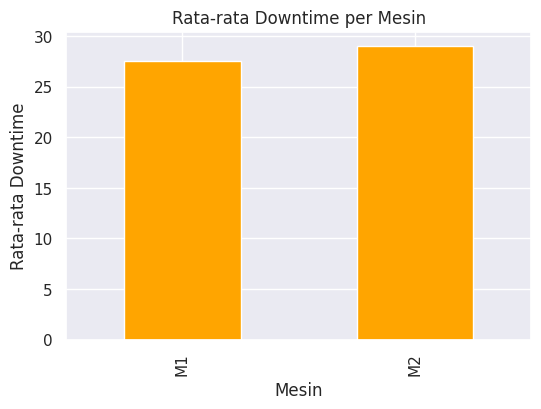

In [ ]:
# =============================================================================
# RATA-RATA DOWNTIME PER MESIN
# =============================================================================
# Membandingkan rata-rata downtime antar-mesin untuk identifikasi mesin bermasalah

avg_downtime_mesin = df.groupby('Mesin')['Downtime_Menit'].mean()
avg_downtime_mesin.plot(kind='bar', figsize=(6,4), title='Rata-rata Downtime per Mesin', color='orange')
plt.ylabel('Rata-rata Downtime')
plt.show()

## 10. Visualisasi Bivariat: Scatter Plot Hubungan Dua Variabel

Scatter plot menunjukkan hubungan antara dua variabel numerik. Misalnya, hubungan negatif antara downtime dan output mengindikasikan bahwa henti produksi menurunkan output.

Text(0, 0.5, 'Output Unit')

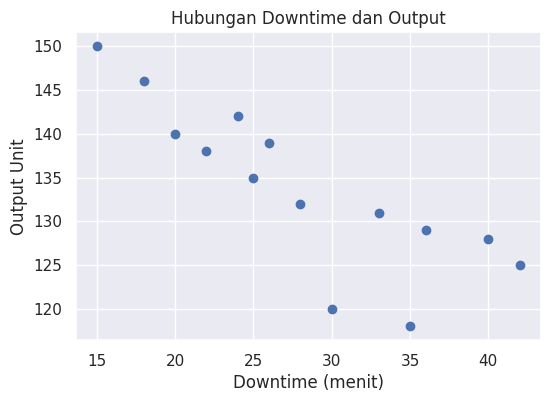

In [ ]:
# =============================================================================
# SCATTER PLOT: DOWNTIME vs OUTPUT
# =============================================================================
# plt.scatter(x, y): membuat titik untuk setiap observasi
# Jika tren menurun, berarti downtime tinggi berkorelasi dengan output rendah

plt.figure(figsize=(6,4))
plt.scatter(df['Downtime_Menit'], df['Output_Unit'])
plt.title('Hubungan Downtime dan Output')
plt.xlabel('Downtime (menit)')
plt.ylabel('Output Unit')

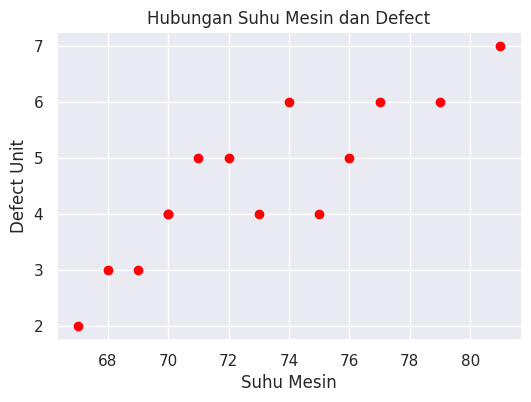

In [ ]:
# =============================================================================
# SCATTER PLOT: SUHU MESIN vs DEFECT
# =============================================================================
# Suhu mesin tinggi dapat meningkatkan defect (kualitas menurun)

plt.figure(figsize=(6,4))
plt.scatter(df['Suhu_Mesin'], df['Defect_Unit'], color='red')
plt.title('Hubungan Suhu Mesin dan Defect')
plt.xlabel('Suhu Mesin')
plt.ylabel('Defect Unit')
plt.show()

## 11. Analisis Korelasi Linier Antar-Variabel

Matriks korelasi menunjukkan kekuatan dan arah hubungan linier antarvariabel numerik. Nilai korelasi berkisar dari -1 (negatif sempurna) hingga +1 (positif sempurna). Korelasi tidak menyiratkan sebab-akibat, tetapi berguna untuk hipotesis awal.

In [ ]:
# =============================================================================
# MENGGUNAKAN FUNGSI .corr() UNTUK MENGGUNAKAN MATRIKS KORELASI
# =============================================================================
# .corr() menghitung korelasi Pearson antar kolom numerik
# Hasil: tabel korelasi dengan nilai -1 hingga 1

corr = df[['Output_Unit','Downtime_Menit','Defect_Unit','Operator_Hadir','Suhu_Mesin','Selisih_Target']].corr()
corr

,Output_Unit,Downtime_Menit,Defect_Unit,Operator_Hadir,Suhu_Mesin,Selisih_Target
Output_Unit,1.000000,-0.833321,-0.867760,0.019952,-0.622655,0.951280
Downtime_Menit,-0.833321,1.000000,0.975205,-0.387529,0.931492,-0.767872
Defect_Unit,-0.867760,0.975205,1.000000,-0.318441,0.876092,-0.805832
Operator_Hadir,0.019952,-0.387529,-0.318441,1.000000,-0.624152,0.075717
Suhu_Mesin,-0.622655,0.931492,0.876092,-0.624152,1.000000,-0.605508
Selisih_Target,0.951280,-0.767872,-0.805832,0.075717,-0.605508,1.000000


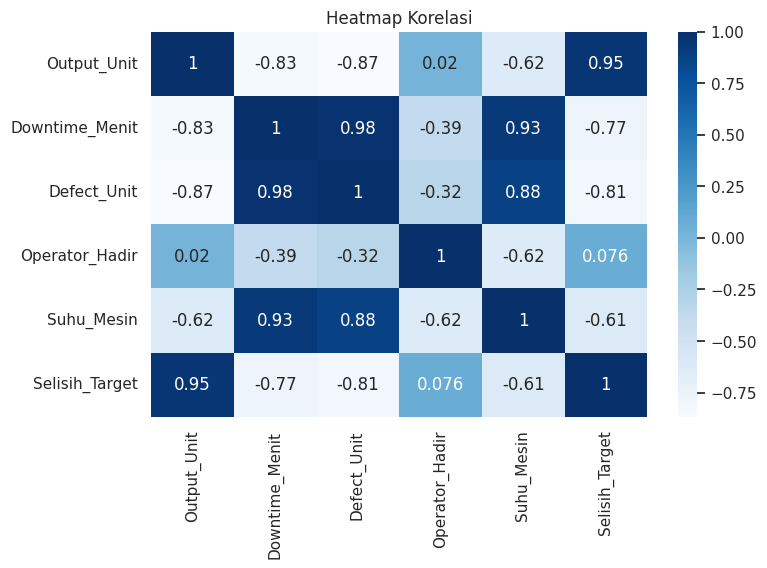

In [ ]:
# =============================================================================
# VISUALISASI MATRIKS KORELASI DENGAN HEATMAP
# =============================================================================
# sns.heatmap(): memvisualisasikan matriks sebagai peta warna
# annot=True: menampilkan angka di setiap sel
# cmap='Blues': skema warna biru (semakin gelap = korelasi lebih kuat)

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Heatmap Korelasi')
plt.show()

## 12. Contoh Interpretasi Hasil EDA

Berikut adalah contoh insight yang dapat disimpulkan dari analisis di atas:
- Output cenderung menurun saat downtime tinggi (korelasi negatif).
- Mesin M2 tampak memiliki downtime lebih besar dibanding M1.
- Suhu mesin yang lebih tinggi berkorelasi dengan jumlah defect lebih besar.
- Shift Pagi rata-rata memiliki output lebih baik dibanding Shift Siang.

Tujuan EDA adalah menghasilkan **hipotesis berbasis data**, bukan kesimpulan definitif.

## 13. Aktivitas Kolaboratif Kelompok

Dalam kelompok kecil (2–3 orang), jawab pertanyaan berikut di markdown cell:
1. Tiga insight utama dari EDA ini.
2. Satu variabel yang paling menarik untuk dianalisis lebih lanjut.
3. Satu target prediksi yang relevan untuk sesi pemodelan berikutnya.
4. Satu kemungkinan masalah kualitas data yang teridentifikasi.